<a href="https://colab.research.google.com/github/sebastiangutierrez4-lgtm/AnalisisDatosBancoMundial.ipynb/blob/main/Portafolio_LendingClub_FINAL_v4_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo de Portafolio Semestral — Réplica y extensión de un paper de ML
### Versión final

**Curso:** Ciencia de Datos para la Economía
**Profesor:** Luis Cuevas Parra
**Año:** 2026

**Paper seleccionado (Bloque B — Riesgo financiero, crédito y clientes, #6):**

> Moscato, V., Picariello, A., & Sperlí, G. (2021). *A benchmark of machine learning approaches for credit score prediction.* Expert Systems with Applications, 165, 113986. https://doi.org/10.1016/j.eswa.2020.113986

- **Revista / cuartil:** Expert Systems with Applications — Q1 (Artificial Intelligence / Computer Science Applications, SCImago 2024)
- **Modelo(s) de ML del paper:** Regresión logística, árboles de decisión, random forest, redes neuronales y métodos de ensamble, con técnicas de balanceo de clases (submuestreo/sobremuestreo).
- **Datos:** Préstamos P2P de LendingClub, originados en 2016-2017 (877.956 registros, 151 variables en el paper original), disponibles en Kaggle ("All Lending Club loan data").

**Integrantes del grupo:**
- Carla Aguilera
- Joaquín Flores
- Sebastián Gutiérrez
- Benjamín Romero

**Cambios respecto a la versión anterior (fidelidad al paper):**
1. Se filtra el dataset a préstamos originados en **2016-2017**, igual que los autores (antes se usaba el histórico completo 2007-2018).
2. Se reemplaza **SMOTE por Random Under-Sampling (RUS)** en Regresión Logística y Random Forest, ya que la combinación ganadora del paper es **RF + RUS**, no sobremuestreo.
3. Se agregan límites de profundidad/tamaño a Random Forest para hacerlo viable en equipos con RAM limitada (antes tardaba +200 min en un M1 8GB).
4. Se agrega la métrica de **Specificity**, ya que el paper reporta AUC, Sensitivity y Specificity (no Precision/F1 explícitamente).
5. Se documentan las limitaciones que **no** se pueden cerrar (151 vs. ~19 variables; técnicas de explicabilidad LIME/SHAP del paper, fuera del alcance de este trabajo).

---


## 1. Resumen del paper

**Pregunta de investigación:** ¿Qué tan bien predicen distintos algoritmos de Machine Learning
el riesgo crediticio (credit scoring) de solicitantes de préstamos P2P bajo distintas técnicas de
balanceo de clases, y cuál combinación modelo+técnica de muestreo ofrece el mejor desempeño
como benchmark?

**Datos utilizados por los autores:** Préstamos de la plataforma LendingClub (EE.UU.),
**originados específicamente en 2016 y 2017**, compuestos por 877.956 registros y 151
variables (datos del solicitante, características del préstamo, estado de pago, etc.). La
variable objetivo es binaria: préstamo pagado (`Fully Paid`) vs. en default (`Charged Off`
y estados equivalentes).

**Metodología (resumen):** Los autores preprocesan los datos (limpieza, imputación,
codificación de variables categóricas) y entrenan varios modelos supervisados de
clasificación —regresión logística, árboles de decisión, random forest y redes neuronales—
combinados con **distintas técnicas de muestreo** para tratar el desbalance de clases:
técnicas de sobremuestreo y, sobre todo, de **submuestreo** (Random Under-Sampling, RUS)
e Instance Hardness Threshold (IHT). Evalúan el desempeño con AUC, Sensitivity (recall) y
Specificity, y adicionalmente analizan la explicabilidad de los tres mejores modelos con
LIME y SHAP.

**Principales resultados del paper:**
- La combinación **Random Forest + Random Under-Sampling (RF-RUS)** obtuvo el mejor
  desempeño global: **AUC ≈ 71,7%**, **accuracy ≈ 64%**, **recall/sensitivity ≈ 63%**.
- En general, los métodos de ensamble (random forest) superaron a la regresión logística,
  aunque la diferencia no es enorme cuando las variables están bien seleccionadas.
- Las técnicas de **submuestreo (RUS/IHT)** dieron mejores resultados que las de
  sobremuestreo para este problema y este dataset en particular.
- El análisis de explicabilidad (LIME/SHAP) identificó variables como la tasa de interés
  (`int_rate`), el grado de riesgo (`grade`) y el ratio deuda/ingreso (`dti`) como las más
  influyentes en la predicción de default — variables que también usamos en este trabajo.

**Nota sobre alcance de la réplica:** el análisis de explicabilidad (LIME/SHAP) del paper
queda fuera del alcance de este portafolio; nos concentramos en replicar el desempeño
predictivo (AUC, Sensitivity, Specificity) de los modelos.

---


## 2. Datos

### 2.1 Fuente de datos

El dataset **"All Lending Club loan data"** está disponible públicamente en Kaggle:

https://www.kaggle.com/datasets/wordsforthewise/lending-club

Contiene información de préstamos P2P originados en la plataforma LendingClub entre
aproximadamente 2007 y 2018, con más de 2 millones de registros y más de 140 variables.
Para acercarnos al diseño experimental de Moscato et al. (2021), en la Sección 2.9
filtramos este dataset a los préstamos **originados en 2016-2017**, tal como hacen los
autores.

### 2.2 Requisitos previos para la descarga

Desde abril de 2024, Kaggle permite descargar **datasets públicos** vía API **sin necesitar
una cuenta ni token**. Por lo tanto, para este dataset en particular es probable que la
descarga funcione directamente (ver sección 2.5).

Aun así, conviene tener credenciales listas como respaldo, ya que algunos datasets exigen
aceptar reglas/términos explícitos antes de permitir la descarga (en ese caso sí es obligatorio
autenticarse):

1. Una cuenta en [kaggle.com](https://www.kaggle.com).
2. Un token de API: en tu perfil de Kaggle → *Settings* → *API* → *Create New Token*. Esto
   descarga un archivo `kaggle.json`.
3. Colocar `kaggle.json` en `~/.kaggle/kaggle.json` (Linux/Mac) o `C:\\Users\\<usuario>\\.kaggle\\kaggle.json` (Windows), o exportar las variables de entorno `KAGGLE_USERNAME` y `KAGGLE_KEY`.
4. Si el dataset lo exige, aceptar sus reglas/términos en la página web de Kaggle antes de
   intentar la descarga vía API.

### 2.3 Instalación de librerías necesarias


In [ ]:
# Ejecutar solo la primera vez / si falta alguna librería
%pip install -q kaggle pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost


### 2.4 Importación de librerías

In [ ]:
import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)


### 2.5 Descarga del dataset desde Kaggle

Desde abril de 2024, Kaggle permite descargar **datasets públicos** a través de su API
**sin necesidad de autenticación** (`kaggle.json`). La excepción son datasets que exigen
aceptar reglas/términos explícitos antes de la descarga, en cuyo caso sí se requiere una
cuenta autenticada (ver sección 2.2).

La celda de abajo primero intenta la descarga **sin autenticar**; si Kaggle exige login para
este dataset en particular, cae automáticamente al flujo autenticado con `kaggle.json`.


In [ ]:
# Opción A: descarga vía Kaggle API (intenta primero sin autenticación,
# y si el dataset lo exige, cae a autenticación con kaggle.json)

# Nota: puede requerir ejecutarse dos veces (la primera tira error) en algunos entornos
KAGGLE_DATASET = "wordsforthewise/lending-club"

from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()

def descargar_dataset(autenticar):
    if autenticar:
        api.authenticate()
    print("Descargando dataset '" + KAGGLE_DATASET + "' (autenticado=" + str(autenticar) + ") ...")
    api.dataset_download_files(KAGGLE_DATASET, path=str(DATA_DIR), unzip=True, quiet=False)
    print("Descarga completa. Archivos disponibles en:", DATA_DIR.resolve())

try:
    descargar_dataset(autenticar=False)
except Exception as e_sin_auth:
    print("La descarga sin autenticación falló (puede que este dataset exija login).")
    print("Detalle:", e_sin_auth)
    print("Intentando con autenticación (requiere kaggle.json, ver seccion 2.2)...")
    try:
        descargar_dataset(autenticar=True)
    except Exception as e_con_auth:
        print("Tampoco se pudo autenticar/descargar con kaggle.json.")
        print("Revisa que el archivo este en ~/.kaggle/kaggle.json y sea valido.")
        print("Detalle:", e_con_auth)


Opción B: descarga manual.

Si la Opción A falla (por ejemplo, por restricciones de red del entorno de ejecución), se puede:

1. Descargar manualmente el .zip desde
   https://www.kaggle.com/datasets/wordsforthewise/lending-club
2. Colocarlo en la carpeta `data/` de este proyecto.
3. Ejecutar la celda siguiente para descomprimirlo.


In [ ]:
# Opción B: descompresión manual de un .zip ya descargado en data/
# En caso de que el anterior falle, dejar una alternativa.
zip_candidates = list(DATA_DIR.glob("*.zip"))

if zip_candidates:
    zip_path = zip_candidates[0]
    print(f"Descomprimiendo {zip_path.name} ...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(DATA_DIR)
    print("Listo.")
else:
    print("No se encontraron archivos .zip en data/. "
          "Si ya ejecutaste la Opción A con éxito, puedes ignorar este mensaje.")


### 2.6 Archivos disponibles tras la descarga

In [ ]:
for f in sorted(DATA_DIR.rglob("*")):
    if f.is_file():
        size_mb = f.stat().st_size / (1024 ** 2)
        rel_path = str(f.relative_to(DATA_DIR))
        print(f"{rel_path:60s}  {size_mb:8.2f} MB")


### 2.7 Carga del dataset principal

El dataset completo es muy grande (millones de filas, >100 columnas), por lo que se recomienda:

- Cargar primero una muestra (`nrows=...`) o solo un subconjunto de columnas para explorar la
  estructura antes de trabajar con el archivo completo.
- Definir en una lista `COLUMNS_TO_USE` las variables relevantes (análogas a las usadas por
  Moscato et al., 2021), para no cargar en memoria las ~150 columnas del archivo original.
- **Importante:** se agrega la columna `issue_d` (fecha de originación del préstamo), necesaria
  para el filtro temporal 2016-2017 de la Sección 2.9.

Ajustar `MAIN_FILE` al nombre real del archivo CSV descargado (por ejemplo `accepted_2007_to_2018Q4.csv.gz` u otro, según la versión del dataset).


In [ ]:
# Ajustar según el/los archivo(s) efectivamente descargados en data/
csv_candidates = [
    f for f in list(DATA_DIR.rglob("*.csv")) + list(DATA_DIR.rglob("*.csv.gz"))
    if f.is_file()  # descarta directorios que compartan el mismo nombre
]
print("Archivos CSV encontrados:")
for f in csv_candidates:
    print(" -", f)

# Preferimos el archivo de préstamos ACEPTADOS (tiene loan_status, grade, etc.)
# por sobre el de rechazados (rejected), que no trae esas columnas.
accepted_files = [f for f in csv_candidates if "accepted" in f.name.lower()]

if accepted_files:
    MAIN_FILE = accepted_files[0]
elif csv_candidates:
    MAIN_FILE = csv_candidates[0]
else:
    MAIN_FILE = None

print("\nMAIN_FILE seleccionado:", MAIN_FILE)


Archivos CSV encontrados:
 - data/rejected_2007_to_2018q4.csv/rejected_2007_to_2018Q4.csv
 - data/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv
 - data/rejected_2007_to_2018Q4.csv.gz
 - data/accepted_2007_to_2018Q4.csv.gz

MAIN_FILE seleccionado: data/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv


In [ ]:
# Columnas de interés, alineadas con las variables típicas usadas en el credit scoring
# de LendingClub (ajustar/completar tras revisar el diccionario de datos y el paper).
# Se agrega "issue_d" (fecha de originación) para poder filtrar por año (Sección 2.9),
# tal como hacen Moscato et al. (2021), quienes usan solo préstamos de 2016-2017.
COLUMNS_TO_USE = [
    "loan_amnt",       # monto del préstamo
    "term",            # plazo (36/60 meses)
    "int_rate",        # tasa de interés
    "installment",     # cuota mensual
    "grade",           # grado de riesgo asignado por LendingClub
    "sub_grade",
    "emp_length",      # antigüedad laboral
    "home_ownership",  # situación de vivienda
    "annual_inc",      # ingreso anual declarado
    "verification_status",
    "purpose",         # propósito del préstamo
    "dti",             # ratio deuda/ingreso
    "delinq_2yrs",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "loan_status",     # variable objetivo (estado del préstamo)
    "issue_d",         # fecha de originación (para filtro 2016-2017)
]

if MAIN_FILE is not None:
    # Primero una muestra pequeña para validar que las columnas existen
    df_sample = pd.read_csv(MAIN_FILE, nrows=5)
    cols_present = [c for c in COLUMNS_TO_USE if c in df_sample.columns]
    cols_missing = [c for c in COLUMNS_TO_USE if c not in df_sample.columns]
    print("Columnas encontradas:", cols_present)
    print("Columnas NO encontradas (revisar nombres):", cols_missing)
else:
    print("MAIN_FILE es None: aún no hay un CSV descargado en data/. "
          "Completa la sección 2.5/2.6 antes de continuar.")


Columnas encontradas: ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'loan_status', 'issue_d']
Columnas NO encontradas (revisar nombres): []


In [ ]:
# Carga completa (o por chunks si el archivo es muy grande) usando solo las columnas de interés
if MAIN_FILE is not None:
    df = pd.read_csv(
        MAIN_FILE,
        usecols=lambda c: c in COLUMNS_TO_USE,
        low_memory=False,
    )
    print("Shape del dataset (histórico completo, antes de filtrar por año):", df.shape)
    display(df.head())
else:
    df = None
    print("Pendiente: descargar el dataset (sección 2.5) antes de cargarlo aquí.")


Shape del dataset (histórico completo, antes de filtrar por año): (2260701, 20)


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,dti,delinq_2yrs,open_acc,pub_rec,revol_bal,revol_util,total_acc
0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,debt_consolidation,5.91,0.0,7.0,0.0,2765.0,29.7,13.0
1,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,small_business,16.06,1.0,22.0,0.0,21470.0,19.2,38.0
2,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,Dec-2015,Fully Paid,home_improvement,10.78,0.0,6.0,0.0,7869.0,56.2,18.0
3,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,Source Verified,Dec-2015,Current,debt_consolidation,17.06,0.0,13.0,0.0,7802.0,11.6,17.0
4,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,Dec-2015,Fully Paid,major_purchase,25.37,1.0,12.0,0.0,21929.0,64.5,35.0


### 2.8 Exploración inicial (EDA preliminar)

In [ ]:
if df is not None:
    print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 20 columns):
 #   Column               Dtype  
---  ------               -----  
 0   loan_amnt            float64
 1   term                 str    
 2   int_rate             float64
 3   installment          float64
 4   grade                str    
 5   sub_grade            str    
 6   emp_length           str    
 7   home_ownership       str    
 8   annual_inc           float64
 9   verification_status  str    
 10  issue_d              str    
 11  loan_status          str    
 12  purpose              str    
 13  dti                  float64
 14  delinq_2yrs          float64
 15  open_acc             float64
 16  pub_rec              float64
 17  revol_bal            float64
 18  revol_util           float64
 19  total_acc            float64
dtypes: float64(11), str(9)
memory usage: 345.0 MB
None


In [ ]:
if df is not None:
    print("Valores faltantes por columna (%):")
    display((df.isna().mean() * 100).sort_values(ascending=False).round(2))


Valores faltantes por columna (%):


emp_length             6.50
revol_util             0.08
dti                    0.08
total_acc              0.00
pub_rec                0.00
open_acc               0.00
delinq_2yrs            0.00
annual_inc             0.00
loan_status            0.00
revol_bal              0.00
purpose                0.00
loan_amnt              0.00
term                   0.00
verification_status    0.00
home_ownership         0.00
sub_grade              0.00
grade                  0.00
installment            0.00
int_rate               0.00
issue_d                0.00
dtype: float64

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
NaN                                                         33
Name: count, dtype: int64

/var/folders/y1/sws8hp854tx58q1yy9m9vmyr0000gn/T/ipykernel_70553/3785915548.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


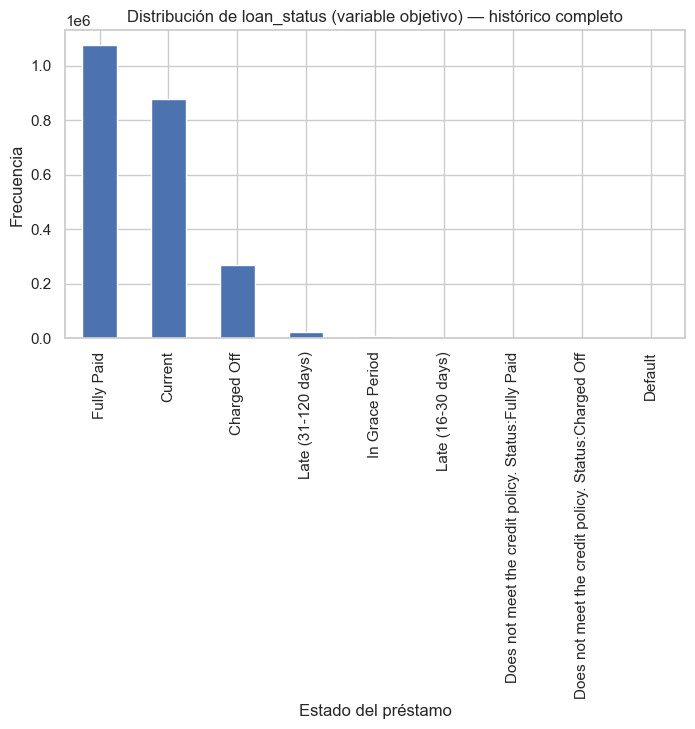

In [ ]:
if df is not None and "loan_status" in df.columns:
    display(df["loan_status"].value_counts(dropna=False))

    plt.figure(figsize=(8, 4))
    df["loan_status"].value_counts().plot(kind="bar")
    plt.title("Distribución de loan_status (variable objetivo) — histórico completo")
    plt.xlabel("Estado del préstamo")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()


In [ ]:
if df is not None:
    display(df.describe(include="number").T)


,count,mean,std,min,25%,50%,75%,max
loan_amnt,2260668.0,15046.931228,9190.245488,500.00,8000.00,12900.00,20000.00,4.000000e+04
int_rate,2260668.0,13.092829,4.832138,5.31,9.49,12.62,15.99,3.099000e+01
installment,2260668.0,445.806823,267.173535,4.93,251.65,377.99,593.32,1.719830e+03
annual_inc,2260664.0,77992.428687,112696.199574,0.00,46000.00,65000.00,93000.00,1.100000e+08
dti,2258957.0,18.824196,14.183329,-1.00,11.89,17.84,24.49,9.990000e+02
delinq_2yrs,2260639.0,0.306879,0.867230,0.00,0.00,0.00,0.00,5.800000e+01
open_acc,2260639.0,11.612402,5.640861,0.00,8.00,11.00,14.00,1.010000e+02
pub_rec,2260639.0,0.197528,0.570515,0.00,0.00,0.00,0.00,8.600000e+01
revol_bal,2260668.0,16658.458078,22948.305028,0.00,5950.00,11324.00,20246.00,2.904836e+06
revol_util,2258866.0,50.337696,24.713073,0.00,31.50,50.30,69.40,8.923000e+02


### 2.9 Filtro temporal: préstamos originados en 2016-2017

Moscato et al. (2021) **no usan todo el histórico** de LendingClub (2007-2018): se enfocan
específicamente en préstamos originados en **2016 y 2017**, lo que en su caso arroja
877.956 registros con 151 variables. Replicamos ese mismo filtro temporal aquí, usando la
columna `issue_d` (fecha de originación del préstamo).

**Razón metodológica (para la discusión de la Sección 7):** los préstamos a 36-60 meses
necesitan tiempo para llegar a un estado terminal (pagado o default). Años muy recientes
dejarían demasiados préstamos aún "Current"; años muy antiguos corresponden a una
plataforma con menor volumen y criterios de originación distintos. 2016-2017 es un punto
intermedio: alto volumen y tiempo suficiente para tener desenlaces definitivos al momento
de la publicación del paper (2020-2021).


In [ ]:
if df is not None and "issue_d" in df.columns:
    df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y")
    n_antes = df.shape[0]
    df = df[df["issue_d"].dt.year.isin([2016, 2017])].copy()
    n_despues = df.shape[0]

    print(f"Registros antes del filtro temporal: {n_antes:,}")
    print(f"Registros tras filtrar a 2016-2017  : {n_despues:,}")
    print(f"Referencia del paper (Moscato et al., 2021): 877,956 registros")
else:
    print("df o 'issue_d' no disponibles todavía.")


Registros antes del filtro temporal: 2,260,701
Registros tras filtrar a 2016-2017  : 877,986
Referencia del paper (Moscato et al., 2021): 877,956 registros


**Nota sobre alcance:** el paper trabaja con 151 variables; nosotros mantenemos un
subconjunto de ~18 variables (Sección 3.4), seleccionadas por ser las más estándar y
citadas en la literatura de credit scoring de LendingClub (monto, tasa, grado de riesgo,
ingreso, dti, historial de cuentas, etc.). Esta es una limitación declarada: no existe forma
de conocer con certeza cuáles de las ~150 columnas originales usaron los autores, ya que el
paper no publica la lista completa. Esto se retoma en la Sección 7.

---


## 3. Preprocesamiento e ingeniería de atributos

En esta sección construimos la variable objetivo binaria, limpiamos tipos de datos,
tratamos los valores faltantes (imputación) y dejamos los datos listos para entrenar
los modelos de la Sección 4.

Orden seguido:

1. Definir la variable objetivo y quedarnos solo con préstamos en estado "terminal"
   (pagados o en default), tal como hacen Moscato et al. (2021).
2. Corregir tipos de columnas que vienen como texto pero son numéricas (`term`,
   `emp_length`, `int_rate`, `revol_util`).
3. Analizar el patrón de valores faltantes.
4. Imputar: mediana para variables numéricas, moda (o categoría "Desconocido") para
   categóricas — usando `SimpleImputer` de scikit-learn dentro de un `Pipeline`, para
   evitar *data leakage* (la imputación se ajusta solo con datos de entrenamiento).
5. Codificar variables categóricas (One-Hot) y escalar las numéricas.
6. Separar en train/test de forma estratificada y balancear las clases del set de
   entrenamiento con **Random Under-Sampling (RUS)** — la técnica que da el mejor
   resultado en el paper (combinación RF-RUS), y además mucho más liviana
   computacionalmente que SMOTE.

### 3.1 Definición de la variable objetivo (`default`)


In [ ]:
if df is not None and "loan_status" in df.columns:
    print("Valores originales de loan_status:")
    display(df["loan_status"].value_counts(dropna=False))

    # Nos quedamos solo con estados "terminales": préstamos totalmente pagados o
    # en default/charged off. Descartamos los que siguen "Current", en gracia, etc.,
    # ya que aún no tienen un desenlace definitivo (igual que en Moscato et al., 2021).
    ESTADOS_PAGADO = ["Fully Paid"]
    ESTADOS_DEFAULT = ["Charged Off", "Default",
                       "Does not meet the credit policy. Status:Charged Off"]
    ESTADOS_PAGADO += ["Does not meet the credit policy. Status:Fully Paid"]

    df_model = df[df["loan_status"].isin(ESTADOS_PAGADO + ESTADOS_DEFAULT)].copy()

    df_model["default"] = df_model["loan_status"].isin(ESTADOS_DEFAULT).astype(int)

    print("\nRegistros tras quedarnos solo con estados terminales:", df_model.shape)
    print("\nDistribución de la variable objetivo (default = 1):")
    display(df_model["default"].value_counts(normalize=True).round(4) * 100)
else:
    df_model = None
    print("df aún no está cargado (ver Sección 2). Esta celda se activará una vez "
          "descargado y filtrado el dataset.")


Valores originales de loan_status:


loan_status
Current               395912
Fully Paid            355005
Charged Off           107390
Late (31-120 days)     12550
In Grace Period         4704
Late (16-30 days)       2394
Default                   31
Name: count, dtype: int64


Registros tras quedarnos solo con estados terminales: (462426, 21)

Distribución de la variable objetivo (default = 1):


default
0    76.77
1    23.23
Name: proportion, dtype: float64

### 3.2 Limpieza de tipos de datos

In [ ]:
if df_model is not None:
    # term viene como " 36 months" / " 60 months" -> lo dejamos como entero
    if "term" in df_model.columns:
        df_model["term"] = (
            df_model["term"].astype(str).str.extract(r"(\d+)").astype(float)
        )

    # emp_length viene como "< 1 year", "1 year", ..., "10+ years" -> lo mapeamos a un
    # entero (0 a 10), preservando el orden (variable numérica/ordinal)
    if "emp_length" in df_model.columns:
        mapa_emp_length = {
            "< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4,
            "5 years": 5, "6 years": 6, "7 years": 7, "8 years": 8, "9 years": 9,
            "10+ years": 10,
        }
        df_model["emp_length"] = df_model["emp_length"].map(mapa_emp_length)

    # int_rate y revol_util a veces vienen como texto con "%" (según la versión del CSV).
    # Usamos is_numeric_dtype en vez de comparar contra `object`, ya que en versiones
    # recientes de pandas las columnas de texto pueden tener dtype "string"/"str" y no
    # necesariamente "object".
    for col in ["int_rate", "revol_util"]:
        if col in df_model.columns and not pd.api.types.is_numeric_dtype(df_model[col]):
            df_model[col] = (
                df_model[col].astype(str).str.replace("%", "", regex=False).astype(float)
            )

    print("Tipos de datos tras la limpieza:")
    display(df_model.dtypes)
else:
    print("df_model no disponible todavía.")


Tipos de datos tras la limpieza:


loan_amnt                     float64
term                          float64
int_rate                      float64
installment                   float64
grade                             str
sub_grade                         str
emp_length                    float64
home_ownership                    str
annual_inc                    float64
verification_status               str
issue_d                datetime64[us]
loan_status                       str
purpose                           str
dti                           float64
delinq_2yrs                   float64
open_acc                      float64
pub_rec                       float64
revol_bal                     float64
revol_util                    float64
total_acc                     float64
default                         int64
dtype: object

### 3.3 Análisis de valores faltantes

Porcentaje de valores faltantes por columna:


emp_length             6.70
revol_util             0.07
dti                    0.05
loan_amnt              0.00
loan_status            0.00
total_acc              0.00
revol_bal              0.00
pub_rec                0.00
open_acc               0.00
delinq_2yrs            0.00
purpose                0.00
issue_d                0.00
term                   0.00
verification_status    0.00
annual_inc             0.00
home_ownership         0.00
sub_grade              0.00
grade                  0.00
installment            0.00
int_rate               0.00
default                0.00
dtype: float64

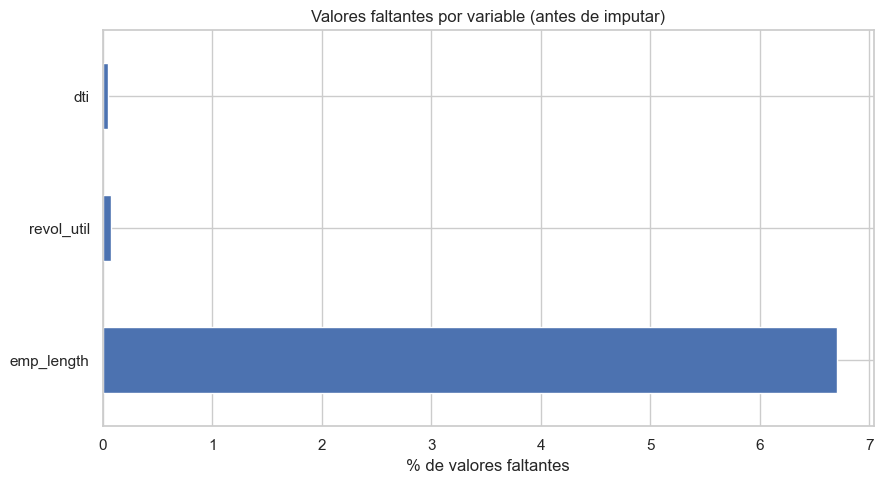

In [ ]:
if df_model is not None:
    faltantes = (df_model.isna().mean() * 100).sort_values(ascending=False)
    print("Porcentaje de valores faltantes por columna:")
    display(faltantes.round(2))

    plt.figure(figsize=(9, 5))
    faltantes[faltantes > 0].plot(kind="barh")
    plt.xlabel("% de valores faltantes")
    plt.title("Valores faltantes por variable (antes de imputar)")
    plt.tight_layout()
    plt.show()
else:
    print("df_model no disponible todavía.")


### 3.4 Definición de variables numéricas y categóricas

Como se vio en clase, la imputación **debe ajustarse solo con el set de entrenamiento**
(para no filtrar información del set de prueba). Por eso no imputamos aquí directamente
sobre `df_model`: en la Sección 3.6 comparamos distintas estrategias de imputación sobre
una muestra, y en la Sección 3.7 armamos el `ColumnTransformer` definitivo que se ajusta
únicamente con `X_train` dentro del `Pipeline` de cada modelo.

In [ ]:
if df_model is not None:
    VARS_NUMERICAS = [c for c in [
        "loan_amnt", "term", "int_rate", "installment", "emp_length", "annual_inc",
        "dti", "delinq_2yrs", "open_acc", "pub_rec", "revol_bal", "revol_util",
        "total_acc",
    ] if c in df_model.columns]

    VARS_CATEGORICAS = [c for c in [
        "grade", "sub_grade", "home_ownership", "verification_status", "purpose",
    ] if c in df_model.columns]

    print("Variables numéricas:", VARS_NUMERICAS)
    print("Variables categóricas:", VARS_CATEGORICAS)

    X = df_model[VARS_NUMERICAS + VARS_CATEGORICAS].copy()
    y = df_model["default"].copy()
else:
    print("df_model no disponible todavía.")


Variables numéricas: ['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc']
Variables categóricas: ['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose']


**Matriz de correlación:** el paper original (Fig. 2) incluye una matriz de
correlación entre variables numéricas para detectar multicolinealidad antes de
modelar. Replicamos ese análisis sobre nuestras variables numéricas.

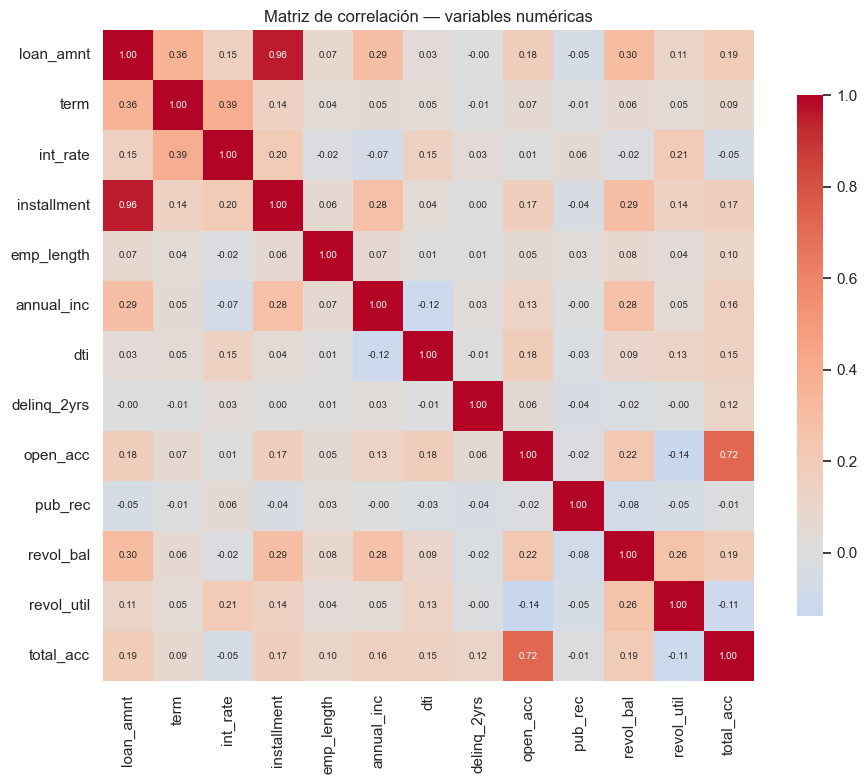

In [ ]:
if df_model is not None:
    matriz_corr = df_model[VARS_NUMERICAS].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        matriz_corr, annot=True, fmt=".2f", cmap="coolwarm",
        center=0, square=True, cbar_kws={"shrink": 0.8},
        annot_kws={"size": 7},
    )
    plt.title("Matriz de correlación — variables numéricas")
    plt.tight_layout()
    plt.show()
else:
    print("df_model no disponible todavía.")


### 3.5 Split train/test estratificado

In [ ]:
if df_model is not None:
    from sklearn.model_selection import train_test_split

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    print("Train:", X_train.shape, " Test:", X_test.shape)
    print("\nProporción de default en train:", y_train.mean().round(4))
    print("Proporción de default en test :", y_test.mean().round(4))
else:
    print("df_model no disponible todavía.")


Train: (369940, 18)  Test: (92486, 18)

Proporción de default en train: 0.2323
Proporción de default en test : 0.2323


### 3.6 Comparación de estrategias de imputación (simple vs. KNN vs. Random Forest)

Antes de fijar con qué imputar las variables numéricas en el pipeline definitivo
(Sección 3.7), comparamos tres estrategias vistas en clase:

1. **Simple** (`SimpleImputer`, mediana): rápida, pero ignora la relación entre
   variables.
2. **KNN** (`KNNImputer`): imputa cada valor faltante con el promedio (ponderado
   por distancia) de sus *k* vecinos más parecidos en las demás variables.
3. **Random Forest / Iterative** (`IterativeImputer` con un `RandomForestRegressor`
   como estimador interno, al estilo *missForest*): imputa cada variable
   entrenando un Random Forest que la predice a partir de las demás, iterando
   varias veces.

**Metodología (validación por enmascaramiento):** tomamos una muestra de filas de
`X_train` que **sí tienen** todos los valores numéricos, ocultamos artificialmente
~15% de esas celdas (simulando faltantes al azar), imputamos con cada método y
comparamos contra el valor real oculto usando **NRMSE** (RMSE normalizado por la
desviación estándar de cada variable, para que columnas de distinta escala —por
ejemplo `loan_amnt` en miles vs. `dti` en decenas— aporten de forma comparable).

**Nota de cómputo:** usamos una muestra acotada (no todo `X_train`), porque KNN e
Iterative Imputer son costosos — con el dataset completo podrían tardar mucho en
una máquina con poca RAM, el mismo problema que ya vimos con SMOTE + Random Forest.
Esta comparación es solo para **elegir** la estrategia; en la Sección 3.7 se decide,
de forma explícita y ajustable, si aplicarla a gran escala o quedarse con la
imputación simple por razones de cómputo.

/Users/benjaminromeroneubauer/mi_proyecto/.venv/lib/python3.14/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,NRMSE promedio
Iterative (Random Forest),0.7438
Simple (mediana),1.0055
KNN (k=5),1.0430


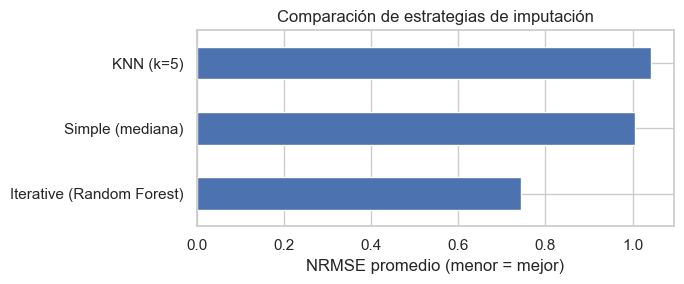


Mejor estrategia de imputación según NRMSE: Iterative (Random Forest)


In [ ]:
if df_model is not None:
    from sklearn.impute import SimpleImputer, KNNImputer
    from sklearn.experimental import enable_iterative_imputer  # noqa: F401 (habilita IterativeImputer)
    from sklearn.impute import IterativeImputer
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.metrics import mean_squared_error
    from sklearn.base import clone

    N_MUESTRA_IMPUTACION = 8000  # ajustar hacia abajo si tu máquina es muy limitada
    PROP_ENMASCARADO = 0.15

    # Nos quedamos solo con filas sin NaN en las variables numéricas, para tener
    # un "terreno de verdad" (ground truth) contra el cual comparar
    completo = X_train[VARS_NUMERICAS].dropna()
    muestra = completo.sample(
        n=min(N_MUESTRA_IMPUTACION, len(completo)), random_state=RANDOM_STATE
    ).copy()

    rng = np.random.RandomState(RANDOM_STATE)
    mask_enmascarado = rng.rand(*muestra.shape) < PROP_ENMASCARADO
    muestra_con_nan = muestra.mask(mask_enmascarado)

    imputadores_candidatos = {
        "Simple (mediana)": SimpleImputer(strategy="median"),
        "KNN (k=5)": KNNImputer(n_neighbors=5),
        "Iterative (Random Forest)": IterativeImputer(
            estimator=RandomForestRegressor(
                n_estimators=20, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1
            ),
            max_iter=5, random_state=RANDOM_STATE,
        ),
    }

    resultados_imputacion = {}
    stds = muestra.std()

    for nombre, imputador in imputadores_candidatos.items():
        imputado = pd.DataFrame(
            clone(imputador).fit_transform(muestra_con_nan),
            columns=muestra.columns, index=muestra.index,
        )
        nrmses_por_columna = []
        for col in muestra.columns:
            idx = mask_enmascarado[:, muestra.columns.get_loc(col)]
            if idx.sum() == 0:
                continue
            y_true = muestra[col].values[idx]
            y_pred = imputado[col].values[idx]
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            nrmses_por_columna.append(rmse / (stds[col] + 1e-9))
        resultados_imputacion[nombre] = np.mean(nrmses_por_columna)

    tabla_imputacion = (
        pd.DataFrame.from_dict(resultados_imputacion, orient="index", columns=["NRMSE promedio"])
        .sort_values("NRMSE promedio")
    )
    display(tabla_imputacion.round(4))

    tabla_imputacion.plot(kind="barh", legend=False, figsize=(7, 3))
    plt.xlabel("NRMSE promedio (menor = mejor)")
    plt.title("Comparación de estrategias de imputación")
    plt.tight_layout()
    plt.show()

    MEJOR_IMPUTADOR_NOMBRE = tabla_imputacion.index[0]
    print(f"\nMejor estrategia de imputación según NRMSE: {MEJOR_IMPUTADOR_NOMBRE}")
else:
    print("df_model no disponible todavía.")


### 3.7 Pipeline de preprocesamiento definitivo (imputación + escalamiento + codificación) y balanceo con RUS

Se arma un `ColumnTransformer` con dos ramas:

- Numéricas: imputador elegido más abajo → `StandardScaler`.
- Categóricas: `SimpleImputer(constante "Desconocido")` → `OneHotEncoder`.

Este preprocesador se combina, dentro de un `imblearn.pipeline.Pipeline`, con
**`RandomUnderSampler` (RUS)** para balancear las clases — solo en el momento de
entrenar (`fit`), nunca se aplica sobre el set de prueba, que debe reflejar la
distribución real de clases.

**Por qué RUS y no SMOTE:**
1. **Fidelidad al paper**: la combinación ganadora de Moscato et al. (2021) es
   **Random Forest + RUS**, no sobremuestreo. Usar RUS nos permite comparar
   "manzanas con manzanas" en la Sección 7.
2. **Eficiencia**: SMOTE genera millones de filas sintéticas para igualar la clase
   mayoritaria; RUS, en cambio, **reduce** la clase mayoritaria al tamaño de la
   minoritaria, resultando en un train set mucho más pequeño y rápido de entrenar.

**Sobre el imputador numérico — costo computacional a gran escala:** que un método
haya ganado en la muestra chica de la Sección 3.6 **no garantiza** que sea viable
aplicarlo a `X_train` completo. `KNNImputer` e `IterativeImputer` con Random Forest
pueden volverse extremadamente lentos con ~1-2 millones de filas en una máquina con
poca RAM. Por eso dejamos un interruptor explícito:

- `USAR_IMPUTACION_AVANZADA = False` (default): usa `SimpleImputer` (mediana) en
  el pipeline completo, aunque KNN o Random Forest hayan ganado en la Sección 3.6
  — se deja documentado cuál ganó, para discutirlo en la Sección 7, priorizando
  que el cuaderno corra en un tiempo razonable.
- `USAR_IMPUTACION_AVANZADA = True`: usa la estrategia ganadora de la Sección 3.6
  también en el pipeline completo. Actívalo solo si tu máquina lo soporta.

In [ ]:
if df_model is not None:
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.under_sampling import RandomUnderSampler

    USAR_IMPUTACION_AVANZADA = False  # cambiar a True solo si tu máquina lo soporta

    if USAR_IMPUTACION_AVANZADA:
        imputador_numerico_final = clone(imputadores_candidatos[MEJOR_IMPUTADOR_NOMBRE])
        print(f"Usando en el pipeline completo: {MEJOR_IMPUTADOR_NOMBRE}")
    else:
        imputador_numerico_final = SimpleImputer(strategy="median")
        print("Usando en el pipeline completo: Simple (mediana), por costo computacional.")
        print(f"(La Sección 3.6 sugiere que '{MEJOR_IMPUTADOR_NOMBRE}' imputa mejor en la muestra chica.)")

    transformador_numerico = Pipeline(steps=[
        ("imputar", imputador_numerico_final),
        ("escalar", StandardScaler()),
    ])

    transformador_categorico = Pipeline(steps=[
        ("imputar", SimpleImputer(strategy="constant", fill_value="Desconocido")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocesador = ColumnTransformer(transformers=[
        ("num", transformador_numerico, VARS_NUMERICAS),
        ("cat", transformador_categorico, VARS_CATEGORICAS),
    ])

    # Random Under-Sampling: reduce la clase mayoritaria (pagados) al tamaño de la
    # clase minoritaria (default), en vez de generar sintéticos como hacía SMOTE.
    rus = RandomUnderSampler(random_state=RANDOM_STATE)

    print("\nPreprocesador (imputación + escalamiento + codificación) listo.")
    print(preprocesador)
    print("\nSampler de balanceo de clases: RandomUnderSampler (RUS)")
else:
    print("df_model no disponible todavía.")


Usando en el pipeline completo: Simple (mediana), por costo computacional.
(La Sección 3.6 sugiere que 'Iterative (Random Forest)' imputa mejor en la muestra chica.)

Preprocesador (imputación + escalamiento + codificación) listo.
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputar',
                                                  SimpleImputer(strategy='median')),
                                                 ('escalar',
                                                  StandardScaler())]),
                                 ['loan_amnt', 'term', 'int_rate',
                                  'installment', 'emp_length', 'annual_inc',
                                  'dti', 'delinq_2yrs', 'open_acc', 'pub_rec',
                                  'revol_bal', 'revol_util', 'total_acc']),
                                ('cat',
                                 Pipeline(steps=[('imputar',
                                                  S

## 4. Modelos del paper (Moscato et al., 2021)

Moscato, Picariello & Sperlí (2021) comparan varios algoritmos de credit scoring
(regresión logística, árboles de decisión, random forest, redes neuronales) combinados
con distintas técnicas de muestreo. Siguiendo la recomendación de la Sección 5.1 de la
pauta, replicamos un subconjunto representativo de **2 modelos**, ambos con **RUS** como
técnica de balanceo (la configuración ganadora del paper):

- **Regresión logística + RUS**: modelo base/clásico, altamente interpretable.
- **Random Forest + RUS**: la combinación destacada por los autores como la de mejor
  desempeño (AUC ≈ 71,7%, accuracy ≈ 64%, recall ≈ 63%).

Ambos se entrenan dentro de un `Pipeline` que incluye el preprocesador de la
Sección 3.7 y el balanceo con RUS, de modo que el flujo completo
(imputación → escalamiento/codificación → RUS → modelo) se ajusta una sola vez
con `fit(X_train, y_train)`.

### 4.1 Función auxiliar de evaluación

Se agrega **Specificity** a las métricas calculadas, ya que el paper reporta
AUC, Sensitivity (= recall) y Specificity explícitamente.


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
)

resultados = []  # aquí se acumulan las métricas de todos los modelos
curvas_roc = {}  # aquí se guardan (fpr, tpr) de cada modelo para graficar juntas


def evaluar_modelo(nombre, pipeline, X_test, y_test, resultados, curvas_roc):
    """Calcula métricas estándar de clasificación y las agrega a `resultados`.

    Incluye Specificity (TNR), FP-Rate y G-Mean para alinear las métricas con
    las que reporta el paper original en su Tabla 4 (AUC, TPR, TNR, FP-Rate,
    G-Mean, ACC).
    """
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")  # TNR
    fp_rate = fp / (tn + fp) if (tn + fp) > 0 else float("nan")       # = 1 - TNR
    recall = recall_score(y_test, y_pred)                              # TPR / Sensitivity
    g_mean = np.sqrt(recall * specificity) if recall >= 0 and specificity >= 0 else float("nan")

    metrica = {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall,          # = TPR / Sensitivity
        "specificity": specificity,  # = TNR
        "fp_rate": fp_rate,
        "g_mean": g_mean,
        "f1": f1_score(y_test, y_pred),
        "auc_roc": roc_auc_score(y_test, y_proba),
    }
    resultados.append(metrica)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    curvas_roc[nombre] = (fpr, tpr, metrica["auc_roc"])

    print(f"--- {nombre} ---")
    for k, v in metrica.items():
        if k != "modelo":
            print(f"  {k:12s}: {v:.4f}")

    ConfusionMatrixDisplay(cm, display_labels=["Pagado", "Default"]).plot(cmap="Blues")
    plt.title(f"Matriz de confusión — {nombre}")
    plt.show()

    return metrica


### 4.2 Modelo 1 — Regresión logística + RUS

--- Regresión logística + RUS ---
  accuracy    : 0.6313
  precision   : 0.3486
  recall      : 0.6758
  specificity : 0.6179
  fp_rate     : 0.3821
  g_mean      : 0.6462
  f1          : 0.4599
  auc_roc     : 0.7050


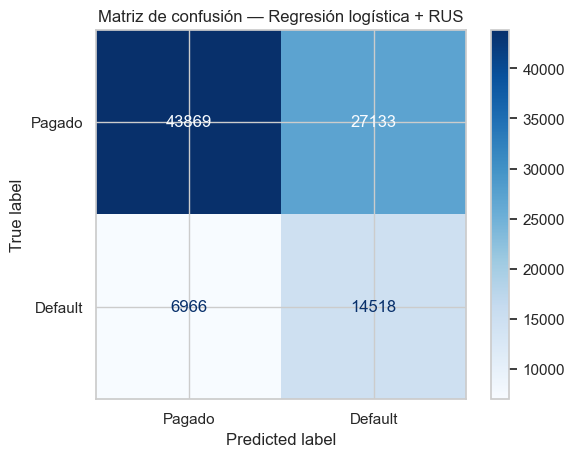

In [ ]:
if df_model is not None:
    from sklearn.linear_model import LogisticRegression

    pipeline_logreg = ImbPipeline(steps=[
        ("preprocesador", preprocesador),
        ("rus", rus),
        ("clasificador", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ])

    pipeline_logreg.fit(X_train, y_train)

    metrica_logreg = evaluar_modelo(
        "Regresión logística + RUS", pipeline_logreg, X_test, y_test, resultados, curvas_roc
    )
else:
    print("df_model no disponible todavía.")


### 4.3 Modelo 2 — Random Forest + RUS

**Ajustes de eficiencia respecto a la versión anterior:** con SMOTE + Random Forest sin
límite de profundidad, el entrenamiento tardaba +200 minutos en un equipo con 8GB de RAM.
Con RUS el train set ya es mucho más pequeño (se reduce, no se infla), y además se acotan
`max_depth` y `min_samples_leaf` para evitar árboles excesivamente grandes — esto regulariza
el modelo y acelera el entrenamiento sin sacrificar demasiado desempeño.


--- Random Forest + RUS ---
  accuracy    : 0.6336
  precision   : 0.3509
  recall      : 0.6788
  specificity : 0.6200
  fp_rate     : 0.3800
  g_mean      : 0.6487
  f1          : 0.4626
  auc_roc     : 0.7071


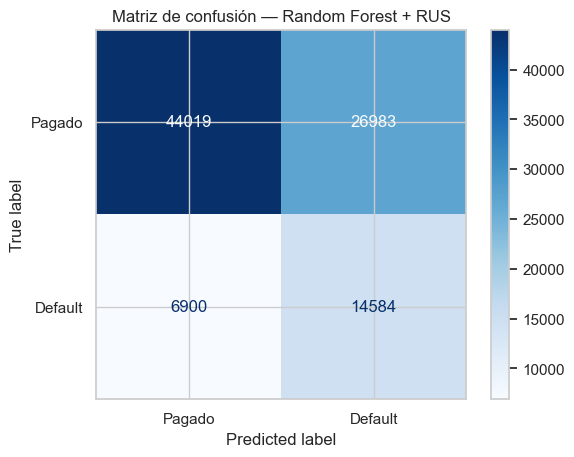

In [ ]:
if df_model is not None:
    from sklearn.ensemble import RandomForestClassifier

    pipeline_rf = ImbPipeline(steps=[
        ("preprocesador", preprocesador),
        ("rus", rus),
        ("clasificador", RandomForestClassifier(
            n_estimators=150,       # antes 300 -- más árboles no siempre es mejor
            max_depth=15,           # antes None -- evita árboles gigantes
            min_samples_leaf=5,     # regulariza y acelera
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])

    pipeline_rf.fit(X_train, y_train)

    metrica_rf = evaluar_modelo(
        "Random Forest + RUS", pipeline_rf, X_test, y_test, resultados, curvas_roc
    )
else:
    print("df_model no disponible todavía.")


## 5. Modelo adicional propuesto por el grupo — XGBoost

**Justificación (Sección 5.2 de la pauta):** proponemos **XGBoost** (`XGBClassifier`),
un modelo de *gradient boosting* de árboles, distinto a los replicados del paper
(regresión logística y random forest, ambos con RUS). Lo elegimos por tres razones:

1. **Boosting en vez de bagging**: a diferencia de Random Forest (que promedia
   muchos árboles independientes), XGBoost construye árboles secuenciales, cada
   uno corrigiendo los errores del anterior — suele capturar mejor interacciones
   no lineales (p. ej. entre `dti`, `int_rate` y `grade`).
2. **Maneja valores faltantes de forma nativa**: `XGBClassifier` aprende, para cada
   nodo, la mejor dirección a tomar cuando un valor es `NaN`, lo que permite
   comparar el efecto de *no* imputar frente a la imputación explícita de la
   Sección 4. Como consecuencia, aquí **no usamos RUS** (que descartaría
   información real al submuestrear) **ni SMOTE** (que no acepta `NaN`): el
   desbalance de clases se compensa con el parámetro nativo `scale_pos_weight`,
   otra estrategia estándar y válida, que además diversifica las técnicas de
   balanceo comparadas en el trabajo (RUS para LR/RF, ponderación nativa para
   boosting) — en la línea de lo que hace el propio paper, que compara RUS
   contra IHT (Instance Hardness Threshold) según el modelo.
3. Es un **benchmark estándar de la industria** para *credit scoring*, visto en
   clase, y no utilizado por Moscato et al. (2021), lo que lo hace un contraste
   interesante frente a Random Forest.

scale_pos_weight = 3.305
--- XGBoost ---
  accuracy    : 0.6452
  precision   : 0.3594
  recall      : 0.6740
  specificity : 0.6365
  fp_rate     : 0.3635
  g_mean      : 0.6550
  f1          : 0.4689
  auc_roc     : 0.7160


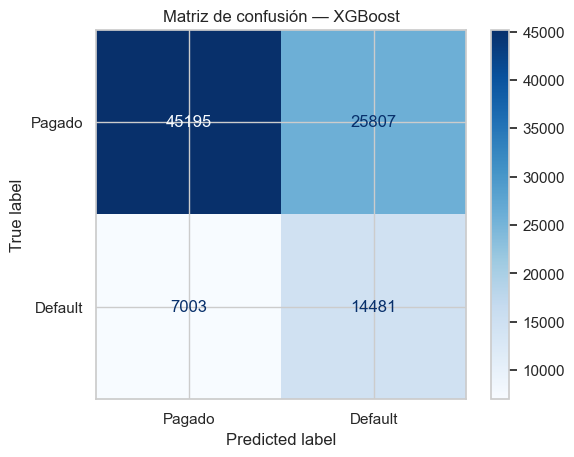

In [ ]:
if df_model is not None:
    from xgboost import XGBClassifier

    # Para este modelo NO usamos el preprocesador con imputación: dejamos los NaN
    # tal cual (solo codificamos las categóricas -> categorías nativas de XGBoost)
    # para aprovechar el manejo nativo de faltantes.
    preprocesador_xgb = ColumnTransformer(transformers=[
        ("num", "passthrough", VARS_NUMERICAS),
        ("cat", OneHotEncoder(handle_unknown="ignore"), VARS_CATEGORICAS),
    ])

    # scale_pos_weight = (# negativos) / (# positivos) en el set de entrenamiento,
    # forma nativa de XGBoost para compensar el desbalance de clases (alternativa
    # a RUS/SMOTE, que no son compatibles con dejar los NaN sin imputar)
    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()
    scale_pos_weight = n_neg / n_pos
    print(f"scale_pos_weight = {scale_pos_weight:.3f}")

    pipeline_xgb = Pipeline(steps=[
        ("preprocesador", preprocesador_xgb),
        ("clasificador", XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

    pipeline_xgb.fit(X_train, y_train)

    metrica_xgb = evaluar_modelo(
        "XGBoost", pipeline_xgb, X_test, y_test, resultados, curvas_roc
    )
else:
    print("df_model no disponible todavía.")


## 6. Comparación de resultados

Reunimos las métricas de los 3 modelos (2 del paper con RUS + 1 propuesto) en una sola
tabla, y graficamos las curvas ROC en un mismo panel para compararlas visualmente.
Se incluye una fila de referencia con los resultados reportados por Moscato et al. (2021)
para su mejor combinación (RF + RUS), de modo que la comparación con el paper quede
explícita en la misma tabla.


,accuracy,precision,recall,specificity,fp_rate,g_mean,f1,auc_roc
modelo,,,,,,,,
XGBoost,0.6452,0.3594,0.6740,0.6365,0.3635,0.6550,0.4689,0.7160
Random Forest + RUS,0.6336,0.3509,0.6788,0.6200,0.3800,0.6487,0.4626,0.7071
Regresión logística + RUS,0.6313,0.3486,0.6758,0.6179,0.3821,0.6462,0.4599,0.7050



Tabla comparativa incluyendo las referencias del paper original (Tabla 4):


,accuracy,precision,recall,specificity,fp_rate,g_mean,f1,auc_roc
modelo,,,,,,,,
XGBoost,0.6452,0.3594,0.6740,0.6365,0.3635,0.6550,0.4689,0.7160
Random Forest + RUS,0.6336,0.3509,0.6788,0.6200,0.3800,0.6487,0.4626,0.7071
Regresión logística + RUS,0.6313,0.3486,0.6758,0.6179,0.3821,0.6462,0.4599,0.7050
Referencia paper (LR + RUS),0.6500,NaN,0.6580,0.6400,0.3560,0.6500,NaN,0.7100
Referencia paper (RF + RUS),0.6400,NaN,0.6300,0.6800,0.3200,0.6560,NaN,0.7170


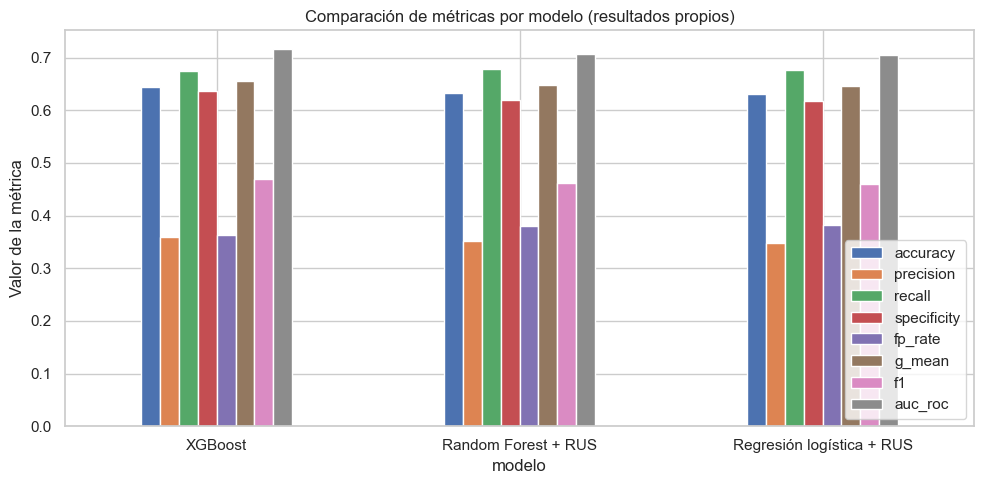

In [ ]:
if df_model is not None:
    tabla_resultados = pd.DataFrame(resultados).set_index("modelo").round(4)
    tabla_resultados = tabla_resultados.sort_values("auc_roc", ascending=False)
    display(tabla_resultados)

    # Referencia del paper (Moscato et al., 2021), Tabla 4 — enfoque Under-Sampling (RUS).
    # Incluimos LR-RUS y RF-RUS (las dos combinaciones que replicamos).
    # Los autores no reportan precision/F1 explícitamente, por eso quedan como NaN.
    referencia_paper = pd.DataFrame([
        {
            "modelo": "Referencia paper (LR + RUS)",
            "accuracy": 0.650,
            "precision": float("nan"),
            "recall": 0.658,       # TPR
            "specificity": 0.640,  # TNR
            "fp_rate": 0.356,
            "g_mean": 0.650,
            "f1": float("nan"),
            "auc_roc": 0.710,
        },
        {
            "modelo": "Referencia paper (RF + RUS)",
            "accuracy": 0.640,
            "precision": float("nan"),
            "recall": 0.630,       # TPR
            "specificity": 0.680,  # TNR
            "fp_rate": 0.320,
            "g_mean": 0.656,
            "f1": float("nan"),
            "auc_roc": 0.717,
        },
    ]).set_index("modelo")

    tabla_comparativa = pd.concat([tabla_resultados, referencia_paper])
    print("\nTabla comparativa incluyendo las referencias del paper original (Tabla 4):")
    display(tabla_comparativa)

    tabla_resultados.plot(kind="bar", figsize=(10, 5))
    plt.title("Comparación de métricas por modelo (resultados propios)")
    plt.ylabel("Valor de la métrica")
    plt.xticks(rotation=0)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
else:
    print("df_model no disponible todavía.")


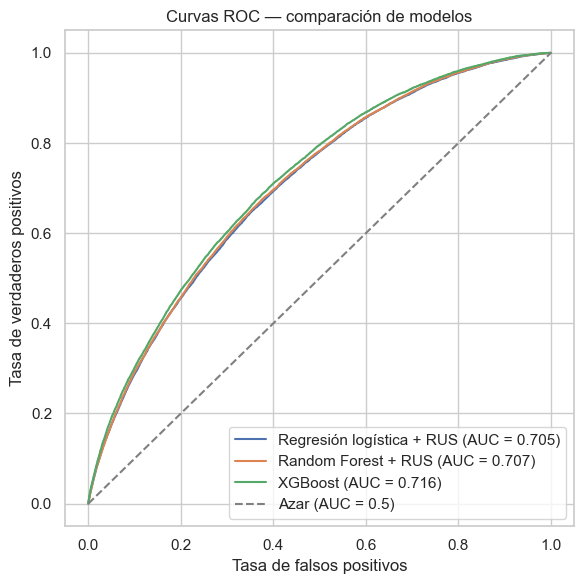

In [ ]:
if df_model is not None:
    plt.figure(figsize=(6, 6))
    for nombre, (fpr, tpr, auc) in curvas_roc.items():
        plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar (AUC = 0.5)")
    plt.xlabel("Tasa de falsos positivos")
    plt.ylabel("Tasa de verdaderos positivos")
    plt.title("Curvas ROC — comparación de modelos")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
else:
    print("df_model no disponible todavía.")


## 7. Discusión y conclusiones